## minimal code

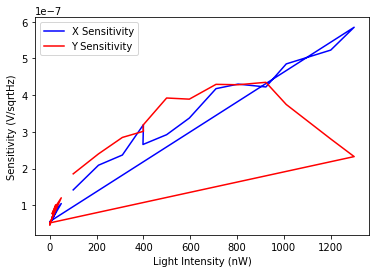

In [118]:
from matplotlib import pyplot as plt
filename = "ShotNoiseQ_1plus.csv"
import pandas as pd


# Plot the file sensitivities as a function of light intensity
plotable = pd.read_csv(filename)
plt.figure()
plt.plot(plotable.LightIntensity, plotable.xSensitivity, label='X Sensitivity'
            , color='blue')
plt.plot(plotable.LightIntensity, plotable.ySensitivity, label='Y Sensitivity'
            , color='red')
plt.xlabel('Light Intensity (nW)')
plt.ylabel('Sensitivity (V/sqrtHz)')
plt.legend()

## Functional

### definition

In [156]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
import itertools

def plot_sensitivity(filenames, labels, lower_bound, upper_bound, showlegend=False, XmaxPlt=np.inf, YmaxPlt=np.inf,YminPlt = 0,XminPlt = 0):
    # Initialize lists to store data
    all_data = []

    # Read and process each file
    for i, filename in enumerate(filenames):
        # Read the CSV file
        plotable = pd.read_csv(filename)

        # Filter the data within the specified bounds
        filtered_data = plotable[(plotable.LightIntensity >= lower_bound) & (plotable.LightIntensity <= upper_bound)]

        # Perform linear regression for X Sensitivity within bounds without intercept
        model_x = LinearRegression(fit_intercept=False)
        model_x.fit(filtered_data.LightIntensity.values.reshape(-1, 1), filtered_data.xSensitivity)
        fit_x_zero_intercept = model_x.predict(plotable.LightIntensity.values.reshape(-1, 1))

        # Perform linear regression for Y Sensitivity within bounds without intercept
        model_y = LinearRegression(fit_intercept=False)
        model_y.fit(filtered_data.LightIntensity.values.reshape(-1, 1), filtered_data.ySensitivity)
        fit_y_zero_intercept = model_y.predict(plotable.LightIntensity.values.reshape(-1, 1))

        # Store data for plotting
        all_data.append({
            "plotable": plotable,
            "filtered_data": filtered_data,
            "fit_x_zero_intercept": fit_x_zero_intercept,
            "fit_y_zero_intercept": fit_y_zero_intercept,
            "label": labels[i]
        })

    # Generate a list of colors
    colors = itertools.cycle(plt.cm.tab20.colors)

    # Plot the original data and the fitted lines for both files
    plt.figure(dpi=300)

    for data in all_data:
        plotable = data["plotable"]
        filtered_data = data["filtered_data"]
        fit_x_zero_intercept = data["fit_x_zero_intercept"]
        fit_y_zero_intercept = data["fit_y_zero_intercept"]

        color_x = next(colors)
        color_y = next(colors)

        plt.plot(plotable.LightIntensity, plotable.xSensitivity, 'o', label=f"X Sensitivity {data['label']}", color=color_x)
        plt.plot(plotable.LightIntensity, plotable.ySensitivity, 'o', label=f"Y Sensitivity {data['label']}", color=color_y)

        # Also plot the fitted lines with intercept
        coeffs_x = np.polyfit(filtered_data.LightIntensity, filtered_data.xSensitivity, 1)
        fit_x = np.polyval(coeffs_x, plotable.LightIntensity)
        coeffs_y = np.polyfit(filtered_data.LightIntensity, filtered_data.ySensitivity, 1)
        fit_y = np.polyval(coeffs_y, plotable.LightIntensity)

        plt.plot(plotable.LightIntensity, fit_x, '--', label=f'X Fit {data["label"]} (y-intercept: {coeffs_x[1]:.2e})', color=color_x)
        plt.plot(plotable.LightIntensity, fit_y, '--', label=f'Y Fit {data["label"]} (y-intercept: {coeffs_y[1]:.2e})', color=color_y)

    plt.xlabel('Light Intensity (nW)')
    plt.ylabel('Sensitivity (V/sqrtHz)')
    if showlegend:
        plt.legend()

    plt.xlim(left=XminPlt)
    plt.ylim(bottom=YminPlt)

    if XmaxPlt != np.inf:
        plt.xlim(right=XmaxPlt)
    if YmaxPlt != np.inf:
        plt.ylim(top=YmaxPlt)

    # plt.show()


### usage

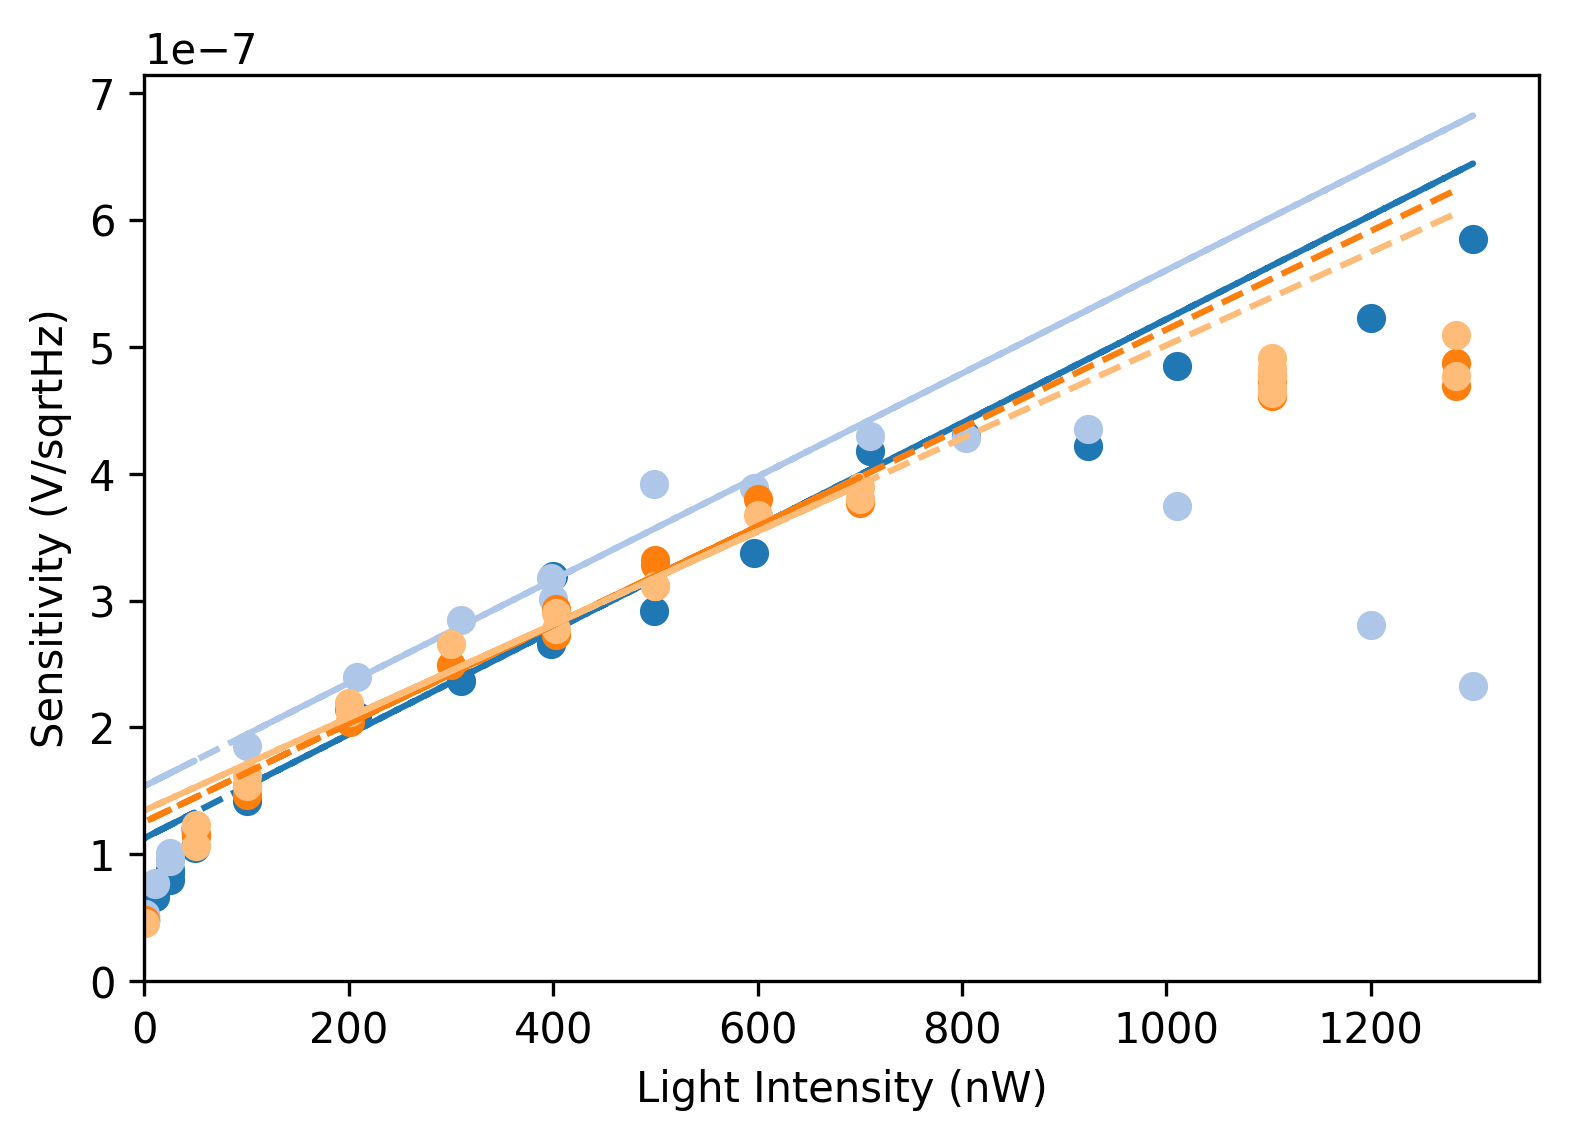

In [134]:

# Usage example
filenames = ["ShotNoiseQ_1plus.csv", "ShotNoiseQ_EOMoff_1.csv"]
labels = ["Q_1plus", "Q_EOMoff"]
lower_bound = 100
upper_bound = 750

plot_sensitivity(filenames, labels, lower_bound, upper_bound)


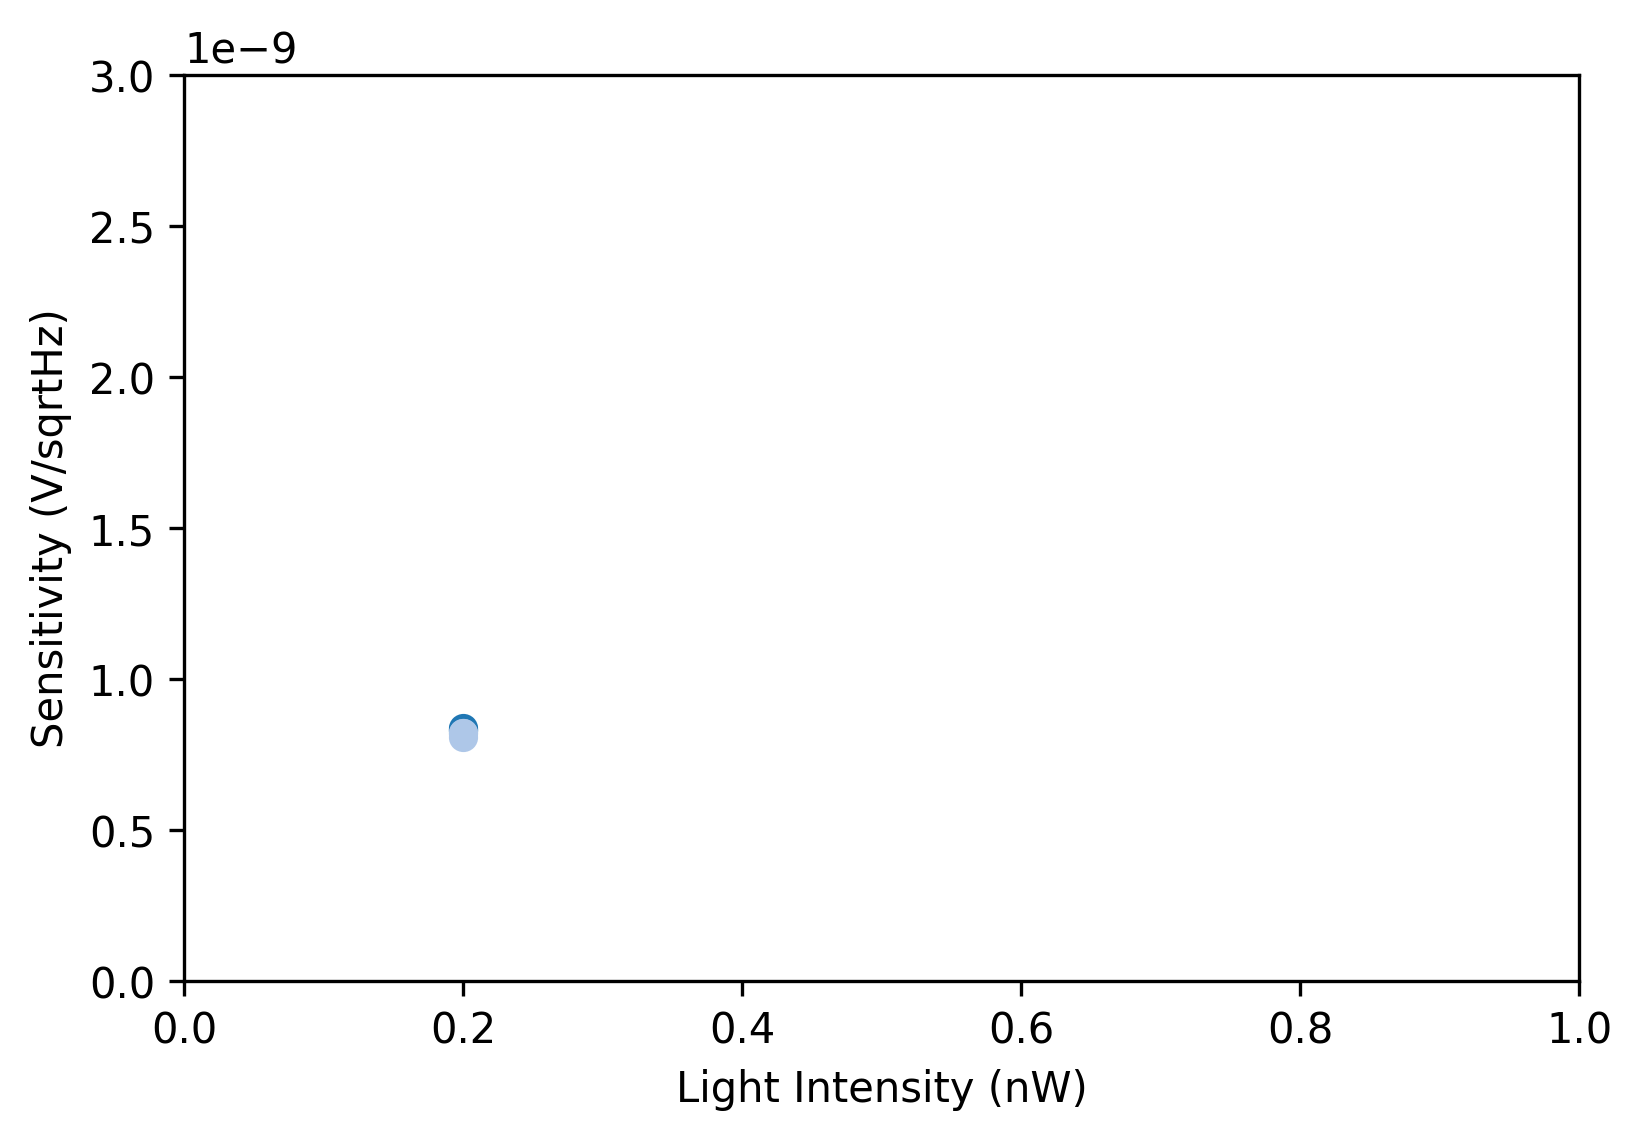

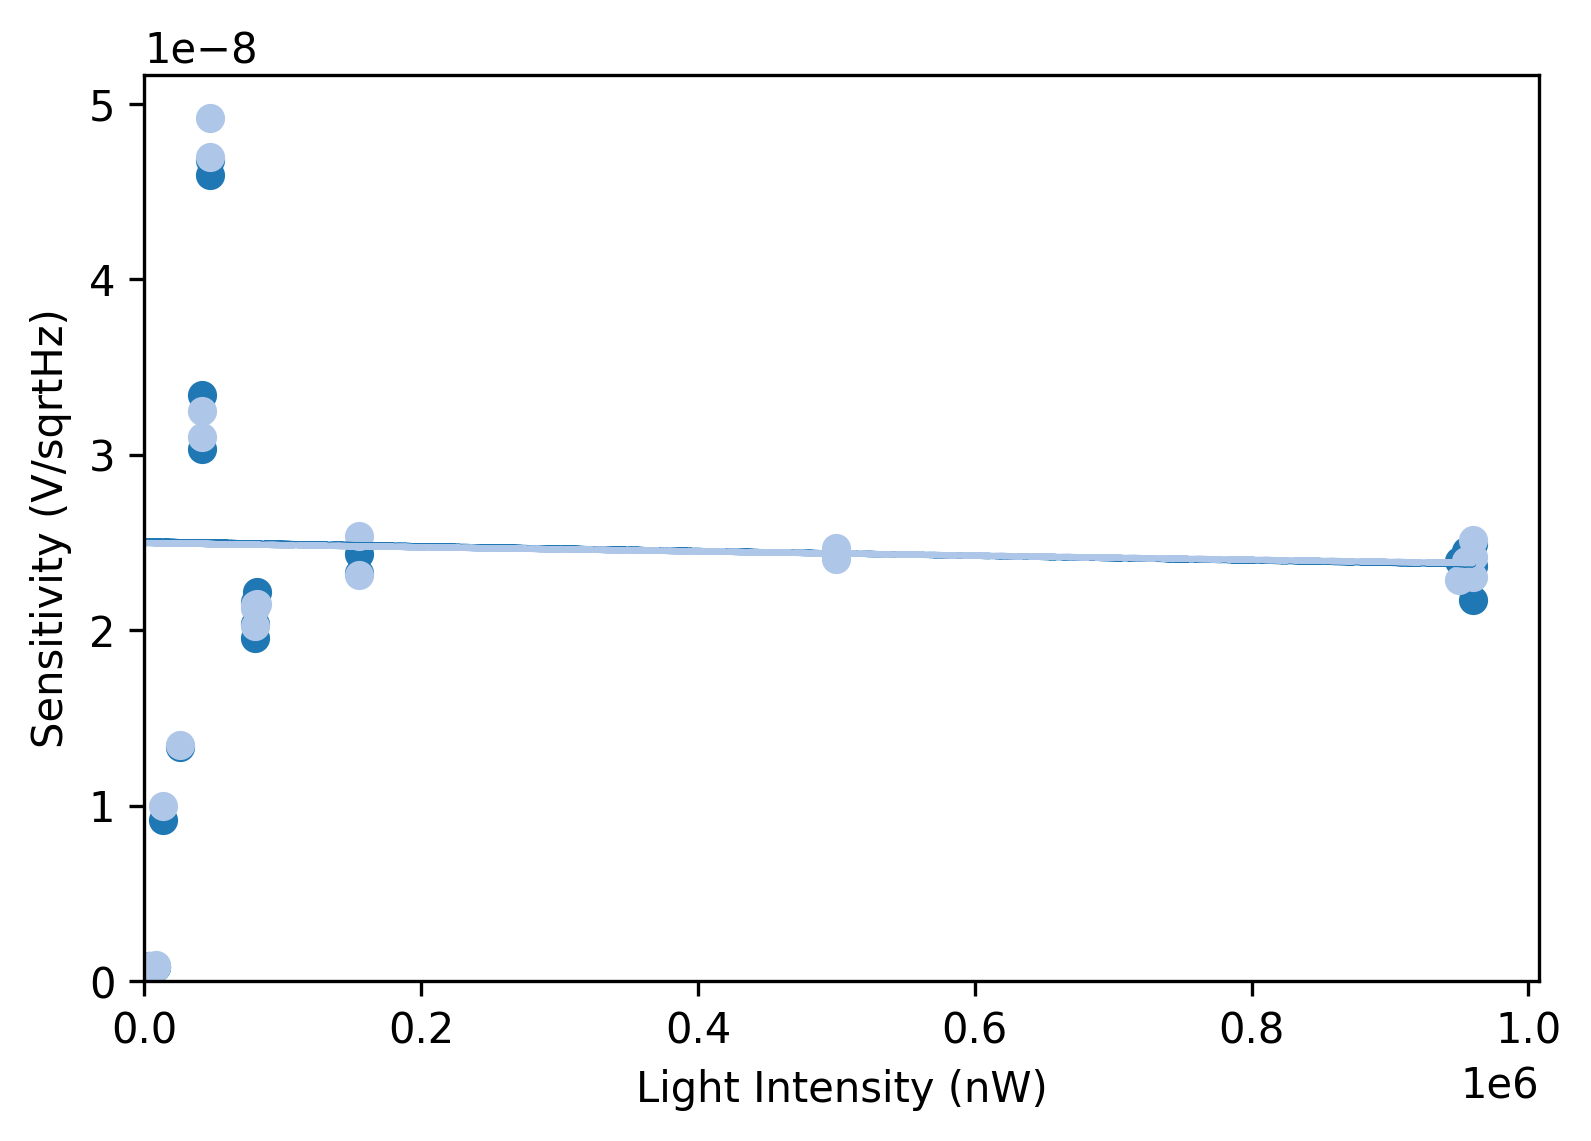

In [170]:
# Usage example
filenames = ["ShotNoiseQ_DET10A.csv"]
labels = ["Q_1plus", "Q_EOMoff", "Q_DET10A"]
lower_bound = 200000
upper_bound = 1000000

plot_sensitivity(filenames, labels, lower_bound, upper_bound, XmaxPlt=1, YmaxPlt=3e-9)
plot_sensitivity(filenames, labels, lower_bound, upper_bound )#, XmaxPlt=85000) #, XminPlt=900000)
# plt.xscale('log')